# 1. Introduction

These notes describe how one can use Python to read, manipulate, visualize, and prepare data, with an eye toward **deep learning**. Whereas classical statistics often lets us hand the data to an estimator more or less as-is, neural networks are demanding guests: they want complete, numeric, *scaled* inputs, and they reward us for having looked at the data carefully beforehand. We shall rely on several modules to make that work:

*   `numpy` for handling arrays.
*   `pandas` for data manipulation and simple analysis.
*   `matplotlib.pyplot` and `seaborn` for static data visualization.
*   `plotly.express` for interactive graphics.
*   `scipy` for accessing statistical functions.
*   `statsmodels` for a linear baseline model.
*   `scikit-learn` for data splitting and feature scaling.
*   `torch` (PyTorch) for turning the final arrays into tensors.

All of these come preinstalled on Google Colab. If you run this notebook on a local installation of Python instead, see the note on Colab versus local installations below.

## 1.1 The Data

As our example, we use the **BostonHousing2** data: 506 census tracts of the Boston metropolitan area, drawn from the 1970 census. The data originate with Harrison and Rubinfeld (1978), who studied the effect of air pollution on housing prices. Gilley and Pace (1996) corrected eight miscoded values of the outcome, and Pace and Gilley (1997) added the longitude and latitude of each tract. This corrected, georeferenced version is what R users know as `BostonHousing2` in the **mlbench** package.

| Variable | Description |
|---|---|
| `town` | town name (92 distinct towns) |
| `tract` | census tract ID (unique per row) |
| `lon`, `lat` | longitude and latitude of the tract |
| `medv` | median value of owner-occupied homes in USD 1000s (original, with errors) |
| `cmedv` | *corrected* median value — our target |
| `crim` | per-capita crime rate |
| `zn` | proportion of residential land zoned for lots over 25,000 sq. ft. |
| `indus` | proportion of non-retail business acres per town |
| `chas` | 1 if the tract bounds the Charles River, 0 otherwise |
| `nox` | nitric oxides concentration (parts per 10 million) |
| `rm` | average number of rooms per dwelling |
| `age` | proportion of owner-occupied units built before 1940 |
| `dis` | weighted distance to five Boston employment centers |
| `rad` | index of accessibility to radial highways (1–8, 24) |
| `tax` | property tax rate per USD 10,000 |
| `ptratio` | pupil–teacher ratio by town |
| `b` | \(1000(B - 0.63)^2\), where \(B\) is the proportion of Black residents |
| `lstat` | percentage of the population classified as lower status |

Two caveats deserve mention before we touch the data.

1.  **Censoring.** The outcome is top-coded: 16 tracts are recorded at exactly \$50,000, the maximum the survey allowed. We will see this clearly in the histogram.
2.  **Ethics.** The variable `b` encodes a racial composition measure built on an assumption from the 1970s hedonic-pricing literature that is, at best, ethically fraught. This is the reason scikit-learn removed its bundled Boston dataset. We keep the variable here because the dataset is a classic teaching example and the issue itself is worth discussing in class — but one should think hard before using such a feature in any real application, and be aware that models trained on it can encode discrimination.

## 1.2 A Note on Colab versus a Local Installation

This notebook is written for **Google Colab**, but nearly everything in it is plain Python and runs anywhere. The genuinely Colab-specific pieces are flagged throughout with the marker **⚠️ Colab-specific**. For reference, the differences are:

*   **Mounting Google Drive.** A Colab notebook runs on a temporary virtual machine in the cloud, which cannot see your files until you *mount* your Google Drive (the `google.colab` module exists only on Colab). On a local installation there is nothing to mount — you simply pass the file's location on your own disk to `pd.read_csv()`.
*   **Installed packages.** Colab preinstalls every module we use. On a local installation you may first need, in a terminal:
    ```
    pip install numpy pandas matplotlib seaborn plotly scipy statsmodels scikit-learn torch
    ```
*   **`display()`.** This pretty-printing function is provided by Jupyter/IPython, so it works in Colab and in Jupyter notebooks alike; in a plain Python script (run from the command line), replace it with `print()`.
*   **Plotly figures.** These render inline in Colab and Jupyter. If an interactive figure comes up blank in a local setup, `fig.show(renderer='browser')` opens it in a browser tab instead.
*   **Hardware.** Colab offers free GPUs (*Runtime ▸ Change runtime type*), which will matter once we train networks; nothing in *this* notebook needs one.

# 2. Reading the Data

The data are in *BostonHousing2.csv*, which you should place in your Google Drive (we assume the folder *Colab Notebooks/python*; adjust the path if you put it elsewhere).

**⚠️ Colab-specific:** we begin by establishing a connection to Google Drive. Running the cell produces a pop-up asking you to authorize access; once mounted, your Drive appears to Python as a folder under `/content/drive/My Drive/`. Since the file is a standard comma-separated file, `pd.read_csv()` needs no further arguments beyond the path.

In [1]:
# --- Colab-specific: mount Google Drive (the google.colab module only exists on Colab)
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Teaching/BostonHousing2.csv')

# --- On a local installation there is nothing to mount: skip the two drive lines
# and pass the file's location on your own disk instead, e.g.
# data = pd.read_csv('/Users/you/Documents/BostonHousing2.csv')          # macOS
# data = pd.read_csv('C:/Users/you/Documents/BostonHousing2.csv')        # Windows

Mounted at /content/drive


# 3. First Inspection

We first obtain an overview of the data, much like `str()` would do in R.

In [2]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   OBS.     506 non-null    int64  
 1   TOWN     506 non-null    object 
 2   TOWN#    506 non-null    int64  
 3   TRACT    506 non-null    int64  
 4   LON      506 non-null    float64
 5   LAT      506 non-null    float64
 6   MEDV     506 non-null    float64
 7   CMEDV    506 non-null    float64
 8   CRIM     506 non-null    float64
 9   ZN       506 non-null    float64
 10  INDUS    506 non-null    float64
 11  CHAS     506 non-null    int64  
 12  NOX      506 non-null    float64
 13  RM       506 non-null    float64
 14  AGE      506 non-null    float64
 15  DIS      506 non-null    float64
 16  RAD      506 non-null    int64  
 17  TAX      506 non-null    int64  
 18  PTRATIO  506 non-null    float64
 19  B        506 non-null    float64
 20  LSTAT    506 non-null    float64
dtypes: float64(14), 

All 21 columns are complete and, apart from the town name, numeric. Do not take this on faith with your own data, however: neural networks cannot digest missing values at all (a single `NaN` propagates through the loss and destroys training), so an explicit check should be routine. If anything shows up here, you must impute or drop *before* modeling.

In [ ]:
# Count missing values per column (all zeros here, but always check)
data.isna().sum()

,0
OBS.,0
TOWN,0
TOWN#,0
TRACT,0
LON,0
LAT,0
MEDV,0
CMEDV,0
CRIM,0
ZN,0


# 4. Wrangling the Data

There is a couple of things we should do:

*   Variable names should be tidied (lowercase, no trailing punctuation).
*   Redundant columns should be dropped: `OBS.` is just a row counter, `TOWN#` duplicates `TOWN` numerically, and `MEDV` is the *uncorrected* outcome — we keep the corrected `CMEDV` and rename it `medv`.
*   The census tract, being unique per row, makes a natural row identifier.

In [3]:
# Tidy the names: lowercase, strip the trailing period from 'OBS.'
data.columns = data.columns.str.lower().str.rstrip('.').str.replace('#', '_id')

# Keep the town name available as a regular column for hover labels later
data['town_name'] = data['town']

# Drop redundant columns and promote the tract ID to row index
data = data.drop(columns=['obs', 'town_id', 'medv'])
data = data.set_index('tract')

# The corrected outcome becomes our 'medv'
data = data.rename(columns={'cmedv': 'medv'})

data.head()

,town,lon,lat,medv,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,town_name
tract,,,,,,,,,,,,,,,,,,
2011,Nahant,-70.955,42.2550,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,Nahant
2021,Swampscott,-70.950,42.2875,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,Swampscott
2022,Swampscott,-70.936,42.2830,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,Swampscott
2031,Marblehead,-70.928,42.2930,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,Marblehead
2032,Marblehead,-70.922,42.2980,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,Marblehead


# 5. Transforming the Data

## 5.1 Skewed Features and the Logarithm

Deep learning optimizers (variants of stochastic gradient descent) behave best when features live on comparable, roughly symmetric scales. The crime rate is a textbook offender: most tracts have almost no crime while a few have a great deal. A log transform tames this. Compare the skewness before and after — a value near 0 indicates symmetry.

In [ ]:
data['log_crim'] = np.log(data['crim'])

print(f"Skewness of crim:     {data['crim'].skew():.2f}")
print(f"Skewness of log_crim: {data['log_crim'].skew():.2f}")

Skewness of crim:     5.22
Skewness of log_crim: 0.41


## 5.2 Encoding Categorical Variables

Neural networks consume numbers, so categorical variables must be encoded. Note that `chas` arrives pre-encoded as a 0/1 dummy. The highway-access index `rad` is more interesting: its values (1–8, then a jump to 24) are labels more than measurements, so one may prefer to treat it as categorical. `pd.get_dummies()` performs one-hot encoding, the Python analogue of R's `model.matrix()`. We demonstrate on a copy so that our working data keep the original column.

One remark specific to deep learning: `town` has 92 levels, and one-hot encoding it would add 91 sparse columns. For such *high-cardinality* categoricals, deep learning offers a more elegant tool — **embedding layers**, which learn a low-dimensional numeric representation of each level during training. We will meet these later in the course; for now, remember that one-hot encoding is for categoricals with few levels.

In [ ]:
# One-hot encode rad on a demonstration copy, ensuring the original variable is not replaced
demo = data.copy()
demo['rad_cat'] = demo['rad'].astype('category')
demo = pd.get_dummies(demo, columns=['rad_cat'], prefix='rad', drop_first=True)

# The new dummy columns:
demo.filter(like='rad_').head()

,rad_2,rad_3,rad_4,rad_5,rad_6,rad_7,rad_8,rad_24
tract,,,,,,,,
2011,False,False,False,False,False,False,False,False
2021,True,False,False,False,False,False,False,False
2022,True,False,False,False,False,False,False,False
2031,False,True,False,False,False,False,False,False
2032,False,True,False,False,False,False,False,False


# 6. Visualization

Visualization is an essential part of machine learning: when we rely this much on our data, we had better get to know them well. For deep learning specifically, four questions guide what we plot:

1.  **What do the distributions look like?** Skewed or wildly differently scaled features tell us what transformations and scaling we need.
2.  **Are there outliers or artifacts?** Censoring, top-coding, and data errors will quietly distort a trained network.
3.  **Are relationships nonlinear?** Nonlinearity is precisely what motivates neural networks over linear models.
4.  **Are features redundant?** Highly correlated inputs are less fatal for neural networks than for OLS, but they still waste capacity and complicate interpretation.

We use `seaborn` (built on `matplotlib`) for quick static graphics and `plotly.express` whenever interactivity — hovering, zooming, panning — earns its keep.

## 6.1 Histograms: Distributions and Artifacts

First the target. Note the isolated spike at 50: this is the censoring we promised — 16 tracts top-coded at \$50,000. A network trained naively on these data will learn to underpredict expensive neighborhoods.

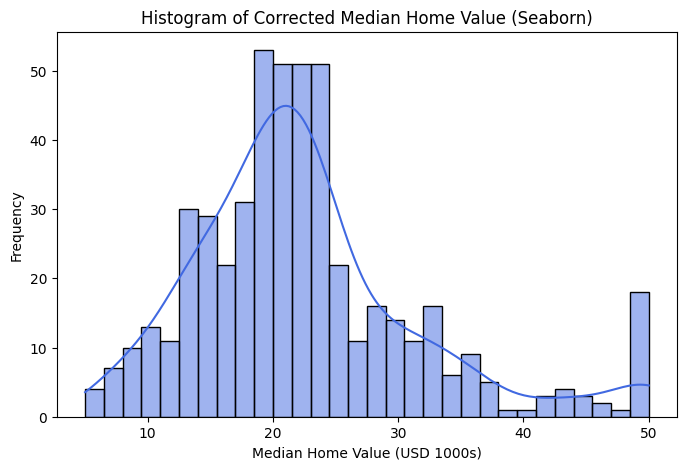

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='medv', bins=30, kde=True, color='royalblue')

plt.xlabel("Median Home Value (USD 1000s)")
plt.ylabel("Frequency")
plt.title("Histogram of Corrected Median Home Value (Seaborn)")

plt.show()

The interactive version lets you hover to read off exact bin counts — try hovering over the spike at 50.

The interactive version lets you hover to read off exact bin counts — try hovering over the spike at 50.

In [ ]:
import plotly.express as px

fig = px.histogram(data, x='medv', nbins=30,
                   title="Histogram of Corrected Median Home Value (Plotly)",
                   labels={'medv': 'Median Home Value (USD 1000s)'},
                   color_discrete_sequence=['royalblue'])

fig.show()

Histograms also justify our log transform of the crime rate. The left panel is unusable — almost all mass is crushed against zero — while the right panel spreads the information out. This is what the optimizer will see, too.

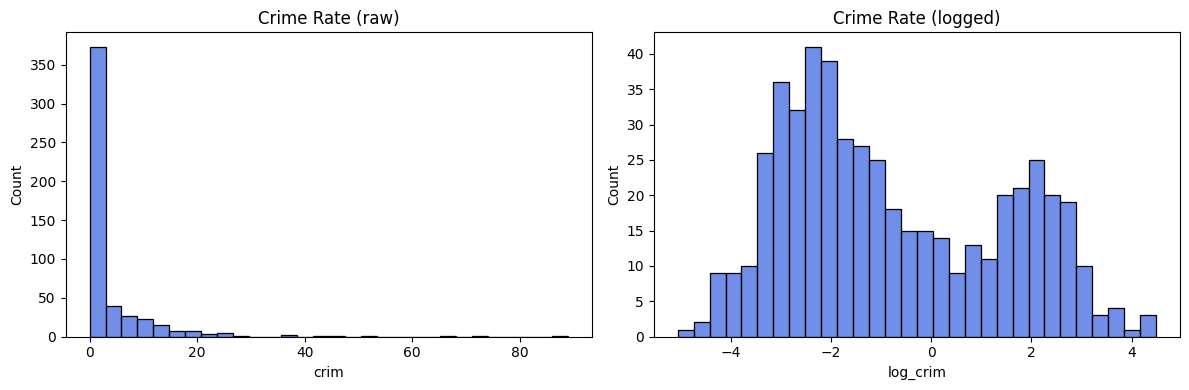

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=data, x='crim', bins=30, color='royalblue', ax=axes[0])
axes[0].set_title("Crime Rate (raw)")

sns.histplot(data=data, x='log_crim', bins=30, color='royalblue', ax=axes[1])
axes[1].set_title("Crime Rate (logged)")

plt.tight_layout()
plt.show()

## 6.2 Box Plots: Group Comparisons and Outliers

Do tracts on the Charles River command higher prices? The interactive box plot shows the five-number summary on hover and marks outliers individually — hover over a point to identify its tract.

In [ ]:
fig = px.box(data, x='chas', y='medv', color='chas',
             title="Median Home Value by Charles River Adjacency (Plotly)",
             labels={'chas': 'Bounds Charles River (0 = no, 1 = yes)',
                     'medv': 'Median Home Value (USD 1000s)'},
             hover_name='town_name')

fig.show()

## 6.3 Scatter Plots: Hunting for Nonlinearity

How does the share of lower-status population relate to home values? The LOWESS smoother (red) bends visibly: the relationship is convex, not linear. This kind of curvature — present in several features here — is exactly what gives flexible models such as neural networks their edge over OLS.

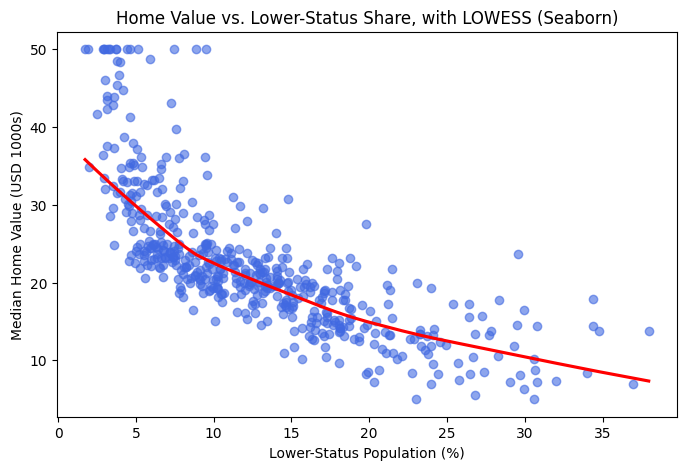

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=data, x='lstat', y='medv', lowess=True,
            scatter_kws={'alpha': 0.6, 'color': 'royalblue'},
            line_kws={'color': 'red'})

plt.xlabel("Lower-Status Population (%)")
plt.ylabel("Median Home Value (USD 1000s)")
plt.title("Home Value vs. Lower-Status Share, with LOWESS (Seaborn)")

plt.show()

The interactive counterpart adds hover labels — useful for asking *which* towns sit where. The horizontal band of points at `medv = 50` is, once again, the censoring.

In [ ]:
fig = px.scatter(data, x='lstat', y='medv',
                 title="Home Value vs. Lower-Status Share (Plotly)",
                 labels={'lstat': 'Lower-Status Population (%)',
                         'medv': 'Median Home Value (USD 1000s)'},
                 opacity=0.7, color='medv', color_continuous_scale='Blues',
                 hover_name='town_name')

fig.show()

## 6.4 Correlation Heatmap: Feature Redundancy

We compute correlations among the main numeric variables. Two things stand out. First, `lstat` and `rm` correlate strongly with the target — promising predictors. Second, `rad` and `tax` correlate at 0.91 with each other: tracts with good highway access are taxed alike. For OLS this multicollinearity inflates standard errors; a neural network will not crash, but redundant inputs add parameters without adding information.

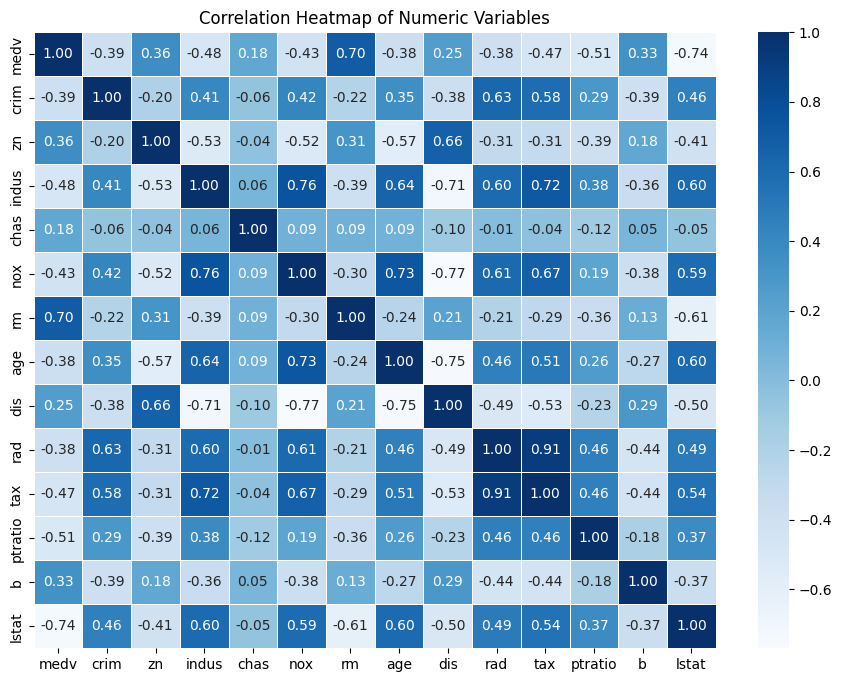

In [ ]:
features = ['medv', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm',
            'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

correlation_matrix = data[features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

## 6.5 Pair Plot: Many Relationships at Once

The following replicates the functionality of GGally in R: LOWESS-smoothed scatter plots below the diagonal, densities on the diagonal, and correlation coefficients above. With 14 numeric variables the full grid would be unreadable, so we restrict attention to the target and four interesting predictors.

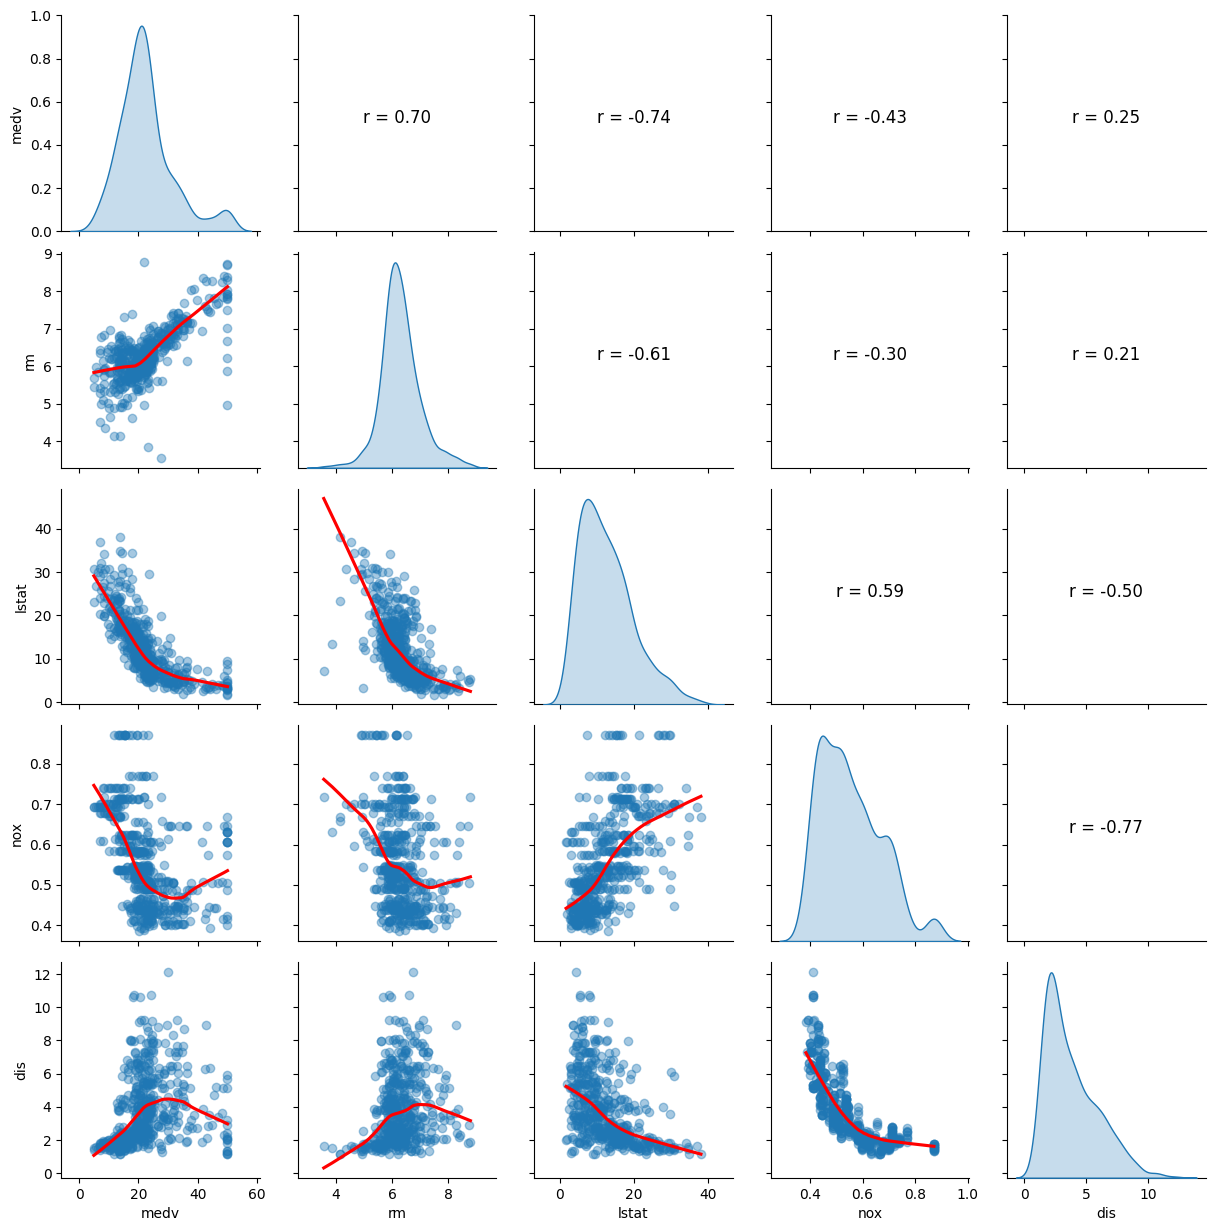

In [ ]:
from scipy.stats import pearsonr

subset = data[['medv', 'rm', 'lstat', 'nox', 'dis']]

g = sns.PairGrid(subset, diag_sharey=False)

# LOESS-like smooth fit for the lower triangle
def loess_fit(x, y, **kwargs):
    sns.regplot(x=x, y=y, lowess=True, scatter_kws={'alpha': 0.4},
                line_kws={'color': 'red'}, **kwargs)

# Correlation annotation for the upper triangle
def corrfunc(x, y, **kwargs):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes,
                ha='center', fontsize=12)

g.map_lower(loess_fit)
g.map_diag(sns.kdeplot, fill=True)
g.map_upper(corrfunc)

plt.show()

## 6.6 An Interactive Map: Spatial Structure

Because Pace and Gilley georeferenced the tracts, we can put the data on a map — something the happiness data never allowed. Zoom and pan; hover for the town and value. The expensive tracts cluster in the western suburbs, the cheap ones in the urban core: home values are **spatially autocorrelated**.

This is not merely pretty. Spatial correlation means observations are not independent, so a purely random train/test split lets information "leak" between neighboring tracts in different folds, and test performance will flatter the model. For seriously spatial data one considers *spatial* cross-validation — a point worth remembering whenever your data have coordinates.

In [ ]:
# Requires plotly >= 5.24; on older versions use px.scatter_mapbox(...,
# mapbox_style="open-street-map") with otherwise identical arguments.
fig = px.scatter_map(data, lat='lat', lon='lon', color='medv',
                     color_continuous_scale='Viridis', zoom=9, height=600,
                     title="Median Home Value across Boston Census Tracts",
                     labels={'medv': 'Home Value'},
                     hover_name='town_name', hover_data={'medv': True, 'lstat': True})

fig.show()

# 7. Descriptive Statistics

We obtain Tukey's five-number summary as well as the mean and standard deviation. Look at the *scales*: `nox` lives on [0.38, 0.87] while `tax` runs into the hundreds. Feed these raw numbers to a neural network and the large-scale features will dominate the early gradients — the case for standardization, which we perform below.

(The `display()` call gives a nicely formatted table. It comes from Jupyter/IPython, so it works in Colab and Jupyter notebooks; in a plain Python script, use `print()` instead.)

In [ ]:
numeric_data = data[features]

summary = numeric_data.describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary[['min', '25%', '50%', '75%', 'max', 'mean', 'std']]
summary.columns = ['Minimum', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)',
                   'Maximum', 'Mean', 'Standard Deviation']

display(summary.round(3))

,Minimum,Q1 (25%),Median (50%),Q3 (75%),Maximum,Mean,Standard Deviation
medv,5.000,17.025,21.200,25.000,50.000,22.529,9.182
crim,0.006,0.082,0.257,3.677,88.976,3.614,8.602
zn,0.000,0.000,0.000,12.500,100.000,11.364,23.322
indus,0.460,5.190,9.690,18.100,27.740,11.137,6.860
chas,0.000,0.000,0.000,0.000,1.000,0.069,0.254
nox,0.385,0.449,0.538,0.624,0.871,0.555,0.116
rm,3.561,5.885,6.208,6.624,8.780,6.285,0.703
age,2.900,45.025,77.500,94.075,100.000,68.575,28.149
dis,1.130,2.100,3.207,5.188,12.126,3.795,2.106
rad,1.000,4.000,5.000,24.000,24.000,9.549,8.707


Skewness gives a quick numeric companion to the histograms: values far from 0 flag candidates for transformation.

In [ ]:
numeric_data.skew().sort_values(ascending=False).round(2)

,0
crim,5.22
chas,3.41
zn,2.23
medv,1.11
dis,1.01
rad,1.00
lstat,0.91
nox,0.73
tax,0.67
rm,0.40


# 8. A Linear Baseline

Before estimating any neural network, one should always fit a simple, interpretable **baseline**. If a deep model cannot beat OLS, the added complexity buys nothing. We regress the corrected home value on the classic thirteen predictors.

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "medv ~ crim + zn + indus + chas + nox + rm + age + dis + rad + tax + ptratio + b + lstat",
    data=data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     110.2
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          1.83e-136
Time:                        17:00:01   Log-Likelihood:                -1494.2
No. Observations:                 506   AIC:                             3016.
Df Residuals:                     492   BIC:                             3076.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.3719      5.058      7.191      0.0

The model explains roughly 74 percent of the variance — a respectable benchmark. But the residual plot below tells a cautionary tale: the errors curve upward at both ends, and the censored tracts form a diagonal streak of large positive residuals. The linear specification is missing systematic structure. *This* is the gap a neural network will try to close.

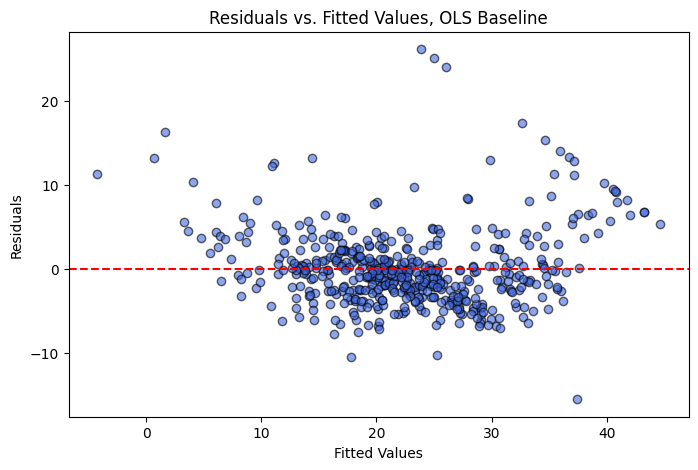

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.6, color='royalblue',
            edgecolors='black')
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values, OLS Baseline")

plt.show()